# Hierarchical analysis

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

## Loading countries data (population and GDP)

In [17]:
countries_df = pd.read_csv('./data/01_gdp_population.csv')
countries_df

,Country Name,Country Code,Population,GDP
0,Afghanistan,AFG,42647492,0.000000
1,Angola,AGO,37885849,2122.083690
2,Albania,ALB,2714617,10011.627986
3,Andorra,AND,81938,49303.673390
4,United Arab Emirates,ARE,10876981,49377.564338
...,...,...,...,...
188,Samoa,WSM,218019,4898.771408
189,"Yemen, Rep.",YEM,40583164,0.000000
190,South Africa,ZAF,64007187,6253.371582
191,Zambia,ZMB,21314956,1235.084665


## Generation of other datasets

### **Company organizational structure dataset**

In [18]:
# Crear datos de estructura organizacional de empresa tech
org_structure = pd.DataFrame({
    'labels': ['Company',
               'Engineering', 'Product', 'Sales', 'Operations',
               'Backend', 'Frontend', 'Mobile', 'DevOps',
               'Design', 'Product Management', 'Analytics',
               'Enterprise', 'SMB', 'Partnerships',
               'HR', 'Finance', 'Legal', 'IT',
               'Backend-Team1', 'Backend-Team2', 'Frontend-Team1', 'Frontend-Team2',
               'Mobile-iOS', 'Mobile-Android', 'DevOps-Cloud', 'DevOps-Security',
               'UI/UX', 'Research', 'PM-Core', 'PM-Growth',
               'Data-Science', 'BI'],
    'parents': ['',
                'Company', 'Company', 'Company', 'Company',
                'Engineering', 'Engineering', 'Engineering', 'Engineering',
                'Product', 'Product', 'Product',
                'Sales', 'Sales', 'Sales',
                'Operations', 'Operations', 'Operations', 'Operations',
                'Backend', 'Backend', 'Frontend', 'Frontend',
                'Mobile', 'Mobile', 'DevOps', 'DevOps',
                'Design', 'Design', 'Product Management', 'Product Management',
                'Analytics', 'Analytics'],
    'values': [500,
               180, 80, 120, 120,
               60, 50, 40, 30,
               30, 25, 25,
               50, 40, 30,
               40, 35, 25, 20,
               30, 30, 25, 25,
               20, 20, 15, 15,
               15, 15, 12, 13,
               13, 12]
})

print(f"Organizacion con {len(org_structure)} unidades")
print(f"Total empleados: {org_structure[org_structure['parents'] == '']['values'].sum()}")

# Mostrar distribucion por departamento
print("\nDistribucion por Departamento Principal:")
dept_dist = org_structure[org_structure['parents'] == 'Company'][['labels', 'values']]
dept_dist.columns = ['Department', 'Employees']
display(dept_dist)

Organizacion con 33 unidades
Total empleados: 500

Distribucion por Departamento Principal:


,Department,Employees
1,Engineering,180
2,Product,80
3,Sales,120
4,Operations,120


In [19]:
org_structure

,labels,parents,values
0,Company,,500
1,Engineering,Company,180
2,Product,Company,80
3,Sales,Company,120
4,Operations,Company,120
5,Backend,Engineering,60
6,Frontend,Engineering,50
7,Mobile,Engineering,40
8,DevOps,Engineering,30
9,Design,Product,30


### **Budget in company's departments dataset**

In [20]:
# Datos de presupuesto por departamento y proyectos
budget_data = pd.DataFrame({
    'department': ['Engineering', 'Engineering', 'Engineering', 'Engineering',
                   'Marketing', 'Marketing', 'Marketing',
                   'Sales', 'Sales', 'Sales',
                   'Research', 'Research', 'Research'],
    'project': ['Cloud Infrastructure', 'Product Development', 'Security', 'Data Pipeline',
                'Digital Campaigns', 'Content Creation', 'Events',
                'CRM System', 'Sales Training', 'Partnerships',
                'AI Research', 'Market Analysis', 'User Studies'],
    'budget': [2500, 3500, 1800, 2200,
               1500, 800, 1200,
               1000, 600, 900,
               2000, 1200, 800]
})

budget_data['category'] = 'Company Budget'

print(f"Presupuesto total: ${budget_data['budget'].sum():,}K")
print(f"Departamentos: {budget_data['department'].nunique()}")
print(f"Proyectos: {len(budget_data)}")

# Mostrar presupuesto por departamento
print("\nPresupuesto por Departamento:")
dept_budget = budget_data.groupby('department')['budget'].agg(['sum', 'count', 'mean']).round(0)
dept_budget.columns = ['Total ($K)', 'Projects', 'Avg per Project ($K)']
display(dept_budget)

Presupuesto total: $20,000K
Departamentos: 4
Proyectos: 13

Presupuesto por Departamento:


,Total ($K),Projects,Avg per Project ($K)
department,,,
Engineering,10000,4,2500.0
Marketing,3500,3,1167.0
Research,4000,3,1333.0
Sales,2500,3,833.0


## **Situation**

Marco Antonelli es el Director General y fuerza impulsora de Terra Cotta Foods (TCF), una de las mayores distribuidoras de productos alimenticios premium y materias primas de Europa. El core de TCF es la adquisición, el procesamiento y la distribución de bienes, por lo que la eficiencia logística y el control de costes son vitales.
 
Marco está planificando una ambiciosa estrategia de expansión hacia América Latina y Asia para diversificar proveedores, asegurar cadenas de suministro y mitigar riesgos geopolíticos.

### **General goal:**

Determine the economic viability and the expansion potential of TCF supply chain in new markets.

### **Supply risks**

What is the correlation between the population (Labor force/Consumer basis) and the economic potential in the countries where Marco pretends to establish supply sources or factories?

### _**Solution**_

To solve this problem, we are going to use the countries dataset, which contains their GDP per capita and population. Based on that, we will find the economic potential by simply find the countries with the higher **Total GDP**, which is the multiplication of _`GDP per Capita * Population`_.

In [21]:
countries_df['Continent'] = [
    "Asia",
    "Europe",
    "Africa",
    "Europe",
    "Africa",
    "Latin America", # Antigua and Barbuda (North America/Caribbean)
    "Latin America", # Argentina (South America)
    "Asia",
    "Oceania",
    "Europe",
    "Asia",
    "Latin America", # Bahamas, The (North America/Caribbean)
    "Asia",
    "Asia",
    "Latin America", # Barbados (North America/Caribbean)
    "Europe",
    "Europe",
    "Latin America", # Belize (North America/Central America)
    "Africa",
    "Asia",
    "Latin America", # Bolivia (South America)
    "Europe",
    "Africa",
    "Latin America", # Brazil (South America)
    "Asia",
    "Europe",
    "Africa",
    "Africa",
    "Africa",
    "Asia",
    "Africa",
    "North America",
    "Africa",
    "Africa",
    "Latin America", # Chile (South America)
    "Asia",
    "Latin America", # Colombia (South America)
    "Africa",
    "Africa",
    "Africa",
    "Latin America", # Costa Rica (North America/Central America)
    "Africa",
    "Europe",
    "Latin America", # Cuba (North America/Caribbean)
    "Europe",
    "Europe",
    "Asia",
    "Europe",
    "Africa",
    "Latin America", # Dominica (North America/Caribbean)
    "Latin America", # Dominican Republic (North America/Caribbean)
    "Latin America", # Ecuador (South America)
    "Africa",
    "Latin America", # El Salvador (North America/Central America)
    "Africa",
    "Africa",
    "Europe",
    "Africa",
    "Africa",
    "Oceania",
    "Europe",
    "Europe",
    "Africa",
    "Africa",
    "Asia",
    "Europe",
    "Africa",
    "Europe",
    "Latin America", # Grenada (North America/Caribbean)
    "Latin America", # Guatemala (North America/Central America)
    "Africa",
    "Africa",
    "Latin America", # Guyana (South America)
    "Latin America", # Haiti (North America/Caribbean)
    "Latin America", # Honduras (North America/Central America)
    "Europe",
    "Europe",
    "Asia",
    "Asia",
    "Asia",
    "Asia",
    "Europe",
    "Asia",
    "Europe",
    "Latin America", # Jamaica (North America/Caribbean)
    "Asia",
    "Asia",
    "Asia",
    "Africa",
    "Oceania",
    "Asia",
    "Asia",
    "Asia",
    "Asia",
    "Europe",
    "Asia",
    "Africa",
    "Africa",
    "Africa",
    "Europe",
    "Europe",
    "Europe",
    "Africa",
    "Africa",
    "Asia",
    "Asia",
    "Africa",
    "Europe",
    "Oceania",
    "Africa",
    "Africa",
    "Latin America", # Mexico (North America/Central America)
    "Oceania",
    "Europe",
    "Europe",
    "Asia",
    "Europe",
    "Africa",
    "Africa",
    "Asia",
    "Africa",
    "Oceania",
    "Asia",
    "Europe",
    "Oceania",
    "Latin America", # Nicaragua (North America/Central America)
    "Africa",
    "Africa",
    "Europe",
    "Europe",
    "Asia",
    "Asia",
    "Oceania",
    "Latin America", # Panama (North America/Central America)
    "Oceania",
    "Latin America", # Paraguay (South America)
    "Latin America", # Peru (South America)
    "Asia",
    "Europe",
    "Europe",
    "Asia",
    "Europe",
    "Asia",
    "Africa",
    "Latin America", # St. Kitts and Nevis (North America/Caribbean)
    "Latin America", # St. Lucia (North America/Caribbean)
    "Latin America", # St. Vincent and the Grenadines (North America/Caribbean)
    "Oceania",
    "Europe",
    "Africa",
    "Asia",
    "Africa",
    "Europe",
    "Africa",
    "Africa",
    "Asia",
    "Europe",
    "Europe",
    "Oceania",
    "Africa",
    "Africa",
    "Africa",
    "Europe",
    "Asia",
    "Africa",
    "Latin America", # Suriname (South America)
    "Europe",
    "Europe",
    "Asia",
    "Asia",
    "Africa",
    "Asia",
    "Asia",
    "Africa",
    "Oceania",
    "Latin America", # Trinidad and Tobago (North America/Caribbean)
    "Africa",
    "Asia",
    "Oceania",
    "Africa",
    "Europe",
    "Asia",
    "Europe",
    "North America",
    "Latin America", # Uruguay (South America)
    "North America",
    "Asia",
    "Oceania",
    "Latin America", # Venezuela, RB (South America)
    "Asia",
    "Asia",
    "Africa",
    "Africa"
]
countries_df['Total GDP'] = (countries_df['GDP'] * countries_df['Population'])
countries_df

,Country Name,Country Code,Population,GDP,Continent,Total GDP
0,Afghanistan,AFG,42647492,0.000000,Asia,0.000000e+00
1,Angola,AGO,37885849,2122.083690,Europe,8.039694e+10
2,Albania,ALB,2714617,10011.627986,Africa,2.717774e+10
3,Andorra,AND,81938,49303.673390,Europe,4.039844e+09
4,United Arab Emirates,ARE,10876981,49377.564338,Africa,5.370788e+11
...,...,...,...,...,...,...
188,Samoa,WSM,218019,4898.771408,Latin America,1.068025e+09
189,"Yemen, Rep.",YEM,40583164,0.000000,Asia,0.000000e+00
190,South Africa,ZAF,64007187,6253.371582,Asia,4.002607e+11
191,Zambia,ZMB,21314956,1235.084665,Africa,2.632578e+10


In [22]:
continents = ['Asia', 'Latin America', 'North America', 'Europe', 'Oceania', 'Africa']
continents_df = []
for continent in continents:
    df = countries_df[countries_df['Continent'] == continent]
    df = df.drop(columns=['Country Name', 'Country Code', 'Continent'])
    continents_df.append(df)

asia = continents_df[0]
latam = continents_df[1]
north_america = continents_df[2]
europe = continents_df[3]
oceania = continents_df[4]
africa = continents_df[5]

In [23]:
asia_correlation_df = asia.corr()
latam_correlation_df = latam.corr()
north_america_correlation_df = north_america.corr()
europe_correlation_df = europe.corr()
oceania_correlation_df = oceania.corr()
africa_correlation_df = africa.corr()

print(f'Correlation metrics in Asia\n{asia_correlation_df}\n')
print(f'Correlation metrics in Latin America\n{latam_correlation_df}\n')
print(f'Correlation metrics in North America\n{north_america_correlation_df}\n')
print(f'Correlation metrics in Europe\n{europe_correlation_df}\n')
print(f'Correlation metrics in Oceania\n{oceania_correlation_df}\n')
print(f'Correlation metrics in Africa\n{africa_correlation_df}\n')


Correlation metrics in Asia
            Population       GDP  Total GDP
Population    1.000000 -0.114945   0.672077
GDP          -0.114945  1.000000   0.163521
Total GDP     0.672077  0.163521   1.000000

Correlation metrics in Latin America
            Population       GDP  Total GDP
Population    1.000000 -0.113480   0.866368
GDP          -0.113480  1.000000   0.154635
Total GDP     0.866368  0.154635   1.000000

Correlation metrics in North America
            Population       GDP  Total GDP
Population    1.000000 -0.778302  -0.660166
GDP          -0.778302  1.000000   0.985429
Total GDP    -0.660166  0.985429   1.000000

Correlation metrics in Europe
            Population       GDP  Total GDP
Population    1.000000  0.166932   0.735839
GDP           0.166932  1.000000   0.429456
Total GDP     0.735839  0.429456   1.000000

Correlation metrics in Oceania
            Population       GDP  Total GDP
Population    1.000000 -0.143392   0.189195
GDP          -0.143392  1.000000   0.8001

The metrics reveal a strong correlation between population and total GDP (the economic potential of the country), meaning that countries with higher population have a higher economic potential. On the other hand, the correlation between GDP per capita and population is weak, showing that a country's wealth per person does not necessarily relate to its population size. This, in terms of Marco's company, **the consumer base should be focused on lower-cost products**.

As additional insights, entering in the African market with very low cost products may be beneficial for most of the population due to their low purchasing power. In addition, the total GDP indicates that it the continent has the potential to welcome the expansion infrastructure of the company.

### **DISCLAIMER**

The last insight is academic only, mentioned to illustate what we could get from the data, but we do not support the idea of expanding to Africa due to the poor labor conditions and human rights violations in many countries of the continent.

In [24]:
filtered_df = countries_df[countries_df['Continent'].isin(['Asia', 'Latin America'])]
filtered_df

,Country Name,Country Code,Population,GDP,Continent,Total GDP
0,Afghanistan,AFG,42647492,0.000000,Asia,0.000000e+00
5,Argentina,ARG,45696159,13858.203980,Latin America,6.332667e+11
6,Armenia,ARM,3033500,8500.605225,Latin America,2.578659e+10
7,Antigua and Barbuda,ATG,93772,23725.790373,Asia,2.224815e+09
10,Azerbaijan,AZE,10202850,7283.835630,Asia,7.431588e+10
...,...,...,...,...,...,...
184,St. Vincent and the Grenadines,VCT,100616,11501.226519,Latin America,1.157207e+09
186,Viet Nam,VNM,100987686,4717.290287,Asia,4.763882e+11
188,Samoa,WSM,218019,4898.771408,Latin America,1.068025e+09
189,"Yemen, Rep.",YEM,40583164,0.000000,Asia,0.000000e+00


C:\Users\ariel\AppData\Local\Temp\ipykernel_2904\271949281.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_df['Total GDP (B USD)'] = filtered_df['Population'] * filtered_df['GDP']


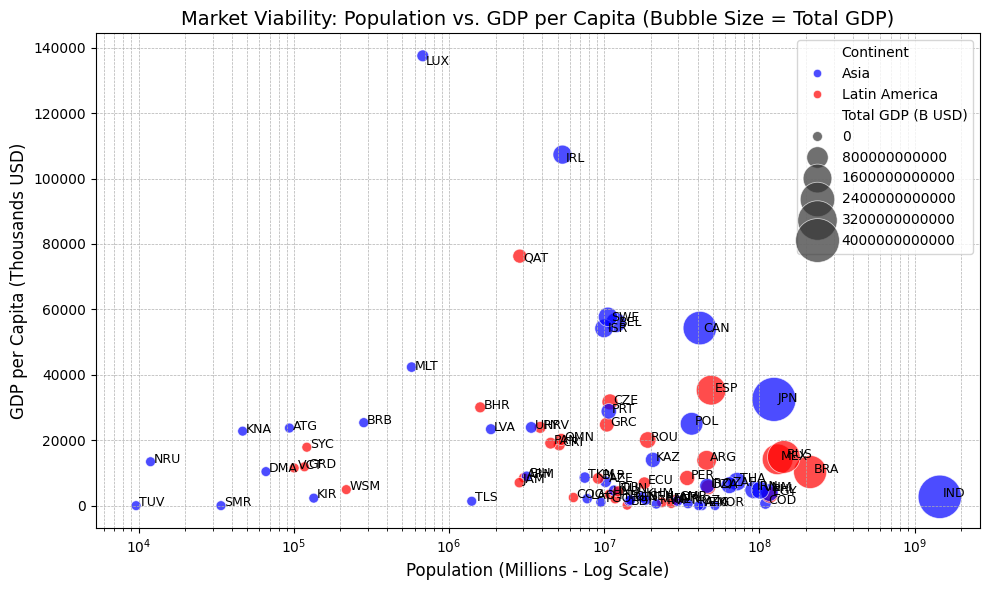

In [25]:
# Calculate the new variable: Total GDP (in Billions USD)
# (Population in M * GDP per Capita in k USD) -> Billion USD
filtered_df['Total GDP (B USD)'] = filtered_df['Population'] * filtered_df['GDP']

# --- VISUALIZATION 1: External Viability (Scatter Plot) ---
plt.figure(figsize=(10, 6))
# Use log scale for Population to handle the wide range of values effectively
scatter = sns.scatterplot(
    data=filtered_df,
    x='Population',
    y='GDP',
    size='Total GDP (B USD)',
    hue='Continent',
    sizes=(50, 1000), # Define min/max size for markers
    alpha=0.7,
    palette={'Latin America': 'red', 'Asia': 'blue'}
)

# Add annotations (country codes)
for i, row in filtered_df.iterrows():
    plt.annotate(row['Country Code'], (row['Population'] * 1.05, row['GDP'] * 0.98), fontsize=9)

plt.title('Market Viability: Population vs. GDP per Capita (Bubble Size = Total GDP)', fontsize=14)
plt.xlabel('Population (Millions - Log Scale)', fontsize=12)
plt.ylabel('GDP per Capita (Thousands USD)', fontsize=12)
plt.xscale('log')
plt.grid(True, which="both", ls="--", linewidth=0.5)
plt.tight_layout()
plt.savefig('market_viability_scatter.png')
plt.show()

In [26]:
"""v2_df = pd.DataFrame(
    {'Job': ['Design', 'Product Management', 'Analytics',
               'Enterprise', 'SMB', 'Partnerships',
               'HR', 'Finance', 'Legal', 'IT',
               'Backend-Team1', 'Backend-Team2', 'Frontend-Team1', 'Frontend-Team2',
               'Mobile-iOS', 'Mobile-Android', 'DevOps-Cloud', 'DevOps-Security',
               'UI/UX', 'Research', 'PM-Core', 'PM-Growth',
               'Data-Science', 'BI'],
     'Subdepartment':['Backend', 'Backend', 'Frontend', 'Frontend',
                'Mobile', 'Mobile', 'DevOps', 'DevOps',
                'Design', 'Design', 'Product Management', 'Product Management',
                'Analytics', 'Analytics'],
     'Department': ['Engineering', 'Engineering', 'Engineering', 'Engineering',
                'Product', 'Product', 'Product',
                'Sales', 'Sales', 'Sales',
                'Operations', 'Operations', 'Operations', 'Operations',],
     'Employees': [60, 50, 40, 30,
               30, 25, 25,
               50, 40, 30,
               40, 35, 25, 20,
               30, 30, 25, 25,
               20, 20, 15, 15,
               15, 15, 12, 13,
               13, 12]
                      }
                     )

v2_df"""

"v2_df = pd.DataFrame(\n    {'Job': ['Design', 'Product Management', 'Analytics',\n               'Enterprise', 'SMB', 'Partnerships',\n               'HR', 'Finance', 'Legal', 'IT',\n               'Backend-Team1', 'Backend-Team2', 'Frontend-Team1', 'Frontend-Team2',\n               'Mobile-iOS', 'Mobile-Android', 'DevOps-Cloud', 'DevOps-Security',\n               'UI/UX', 'Research', 'PM-Core', 'PM-Growth',\n               'Data-Science', 'BI'],\n     'Subdepartment':['Backend', 'Backend', 'Frontend', 'Frontend',\n                'Mobile', 'Mobile', 'DevOps', 'DevOps',\n                'Design', 'Design', 'Product Management', 'Product Management',\n                'Analytics', 'Analytics'],\n     'Department': ['Engineering', 'Engineering', 'Engineering', 'Engineering',\n                'Product', 'Product', 'Product',\n                'Sales', 'Sales', 'Sales',\n                'Operations', 'Operations', 'Operations', 'Operations',],\n     'Employees': [60, 50, 40, 30,\n          